In [1]:
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
imd = gpd.read_file("input/IMD2018.zip")
imd = imd.sort_values("Census_Pop")
imd = imd[imd.columns[~imd.columns.str.startswith(("Rank", "Dec", "Rnk"))]]
imd

,DZ2018,Census_Pop,Count_MB18,dhb2015_co,dhb2015_na,ged2020num,ged2020nam,ta2020code,ta2020name,regc2020co,regc2020na,geometry
3597,6200069,399,1,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1547939.757 5172338.216, 1547940.449..."
5136,7600997,426,6,3,Auckland,1,Auckland Central,76,Auckland,2,Auckland Region,"POLYGON ((1757891.324 5920643.666, 1757896.528..."
3353,6000324,441,15,18,Canterbury,6,Christchurch East,60,Christchurch City,13,Canterbury Region,"POLYGON ((1572232.718 5181122.978, 1572262.997..."
1011,2300119,441,4,7,Bay of Plenty,3,Bay of Plenty,23,Tauranga City,4,Bay of Plenty Region,"POLYGON ((1884176.634 5825838.146, 1884371.67 ..."
691,1700038,447,7,5,Waikato,51,Taupo,17,Waipa District,3,Waikato Region,"POLYGON ((1814939.688 5804286.733, 1814935.622..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2739,5100056,1158,5,16,Nelson Marlborough,27,Nelson,51,Tasman District,16,Tasman Region,"POLYGON ((1614997.769 5422589.824, 1615153.958..."
4590,7600435,1158,9,2,Waitemata,55,Upper Harbour,76,Auckland,2,Auckland Region,"POLYGON ((1753169.876 5930035.056, 1753293.467..."
185,200107,1161,30,1,Northland,64,Whangarei,2,Whangarei District,1,Northland Region,"POLYGON ((1731724.82 6018450.937, 1731920.686 ..."
514,1600078,1272,9,5,Waikato,12,Hamilton East,16,Hamilton City,3,Waikato Region,"POLYGON ((1799974.491 5822341.746, 1800008.251..."


In [3]:
dz = imd.iloc[0:1]
dz

,DZ2018,Census_Pop,Count_MB18,dhb2015_co,dhb2015_na,ged2020num,ged2020nam,ta2020code,ta2020name,regc2020co,regc2020na,geometry
3597,6200069,399,1,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1547939.757 5172338.216, 1547940.449..."


In [4]:
neighbours = imd[imd.geometry.touches(dz.geometry.iloc[0])]
neighbours

,DZ2018,Census_Pop,Count_MB18,dhb2015_co,dhb2015_na,ged2020num,ged2020nam,ta2020code,ta2020name,regc2020co,regc2020na,geometry
3556,6200022,657,8,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1550229.99 5166641.44, 1550604.308 5..."
3558,6200024,675,5,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1549355.411 5173513.952, 1549388.933..."
3560,6200027,894,10,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1549130.727 5170623.434, 1549121.168..."
3598,6200070,1089,1,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1548264.931 5172511.108, 1548265.665..."


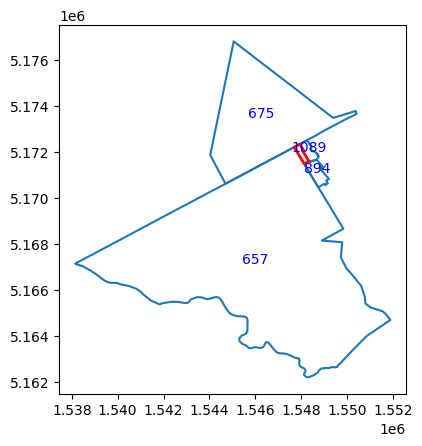

In [5]:
ax = neighbours.boundary.plot()
ax = dz.boundary.plot(ax=ax, color="red", linewidth=2)
#p = dz.centroid.iloc[0]
#ax.annotate(text=str(dz.Census_Pop.iloc[0]), xy=[p.x, p.y], ha='center', color="blue")
for neighbour in neighbours.itertuples():
  p = neighbour.geometry.centroid
  ax.annotate(text=str(neighbour.Census_Pop), xy=[p.x, p.y], ha='center', color="blue")

In [6]:
merged = pd.concat((dz, neighbours.iloc[0:1])).dissolve(aggfunc={
    "DZ2018": "first",
    "Census_Pop": "sum",
    "Count_MB18": "sum",
    "dhb2015_co": "first",
    "dhb2015_na": "first",
    "ged2020num": "first",
    "ged2020nam": "first",
    "ta2020code": "first",
    "ta2020name": "first",
    "regc2020co": "first",
    "regc2020na": "first"
})
merged.index = dz.index
merged

,geometry,DZ2018,Census_Pop,Count_MB18,dhb2015_co,dhb2015_na,ged2020num,ged2020nam,ta2020code,ta2020name,regc2020co,regc2020na
3597,"POLYGON ((1550604.308 5166176.604, 1550771.381...",6200069,1056,9,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region


<Axes: >

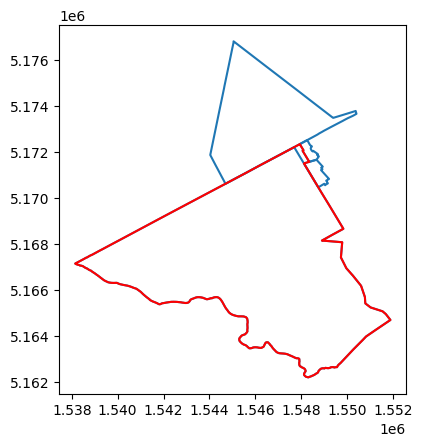

In [7]:
ax = neighbours.boundary.plot()
merged.boundary.plot(ax=ax, color="red")

In [8]:
imd.drop(neighbours.index[0], inplace=True)
imd.update(merged)
imd

,DZ2018,Census_Pop,Count_MB18,dhb2015_co,dhb2015_na,ged2020num,ged2020nam,ta2020code,ta2020name,regc2020co,regc2020na,geometry
3597,6200069,1056,9,18,Canterbury,45,Selwyn,62,Selwyn District,13,Canterbury Region,"POLYGON ((1550604.308 5166176.604, 1550771.381..."
5136,7600997,426,6,3,Auckland,1,Auckland Central,76,Auckland,2,Auckland Region,"POLYGON ((1757891.324 5920643.666, 1757896.528..."
3353,6000324,441,15,18,Canterbury,6,Christchurch East,60,Christchurch City,13,Canterbury Region,"POLYGON ((1572232.718 5181122.978, 1572262.997..."
1011,2300119,441,4,7,Bay of Plenty,3,Bay of Plenty,23,Tauranga City,4,Bay of Plenty Region,"POLYGON ((1884176.634 5825838.146, 1884371.67 ..."
691,1700038,447,7,5,Waikato,51,Taupo,17,Waipa District,3,Waikato Region,"POLYGON ((1814939.688 5804286.733, 1814935.622..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2739,5100056,1158,5,16,Nelson Marlborough,27,Nelson,51,Tasman District,16,Tasman Region,"POLYGON ((1614997.769 5422589.824, 1615153.958..."
4590,7600435,1158,9,2,Waitemata,55,Upper Harbour,76,Auckland,2,Auckland Region,"POLYGON ((1753169.876 5930035.056, 1753293.467..."
185,200107,1161,30,1,Northland,64,Whangarei,2,Whangarei District,1,Northland Region,"POLYGON ((1731724.82 6018450.937, 1731920.686 ..."
514,1600078,1272,9,5,Waikato,12,Hamilton East,16,Hamilton City,3,Waikato Region,"POLYGON ((1799974.491 5822341.746, 1800008.251..."
